<a href="https://colab.research.google.com/github/Abhinav9895/Generative-AI-Internship/blob/main/Day3/unemployed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.lines import lineStyles
from scipy.stats import skew
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [42]:
df=pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


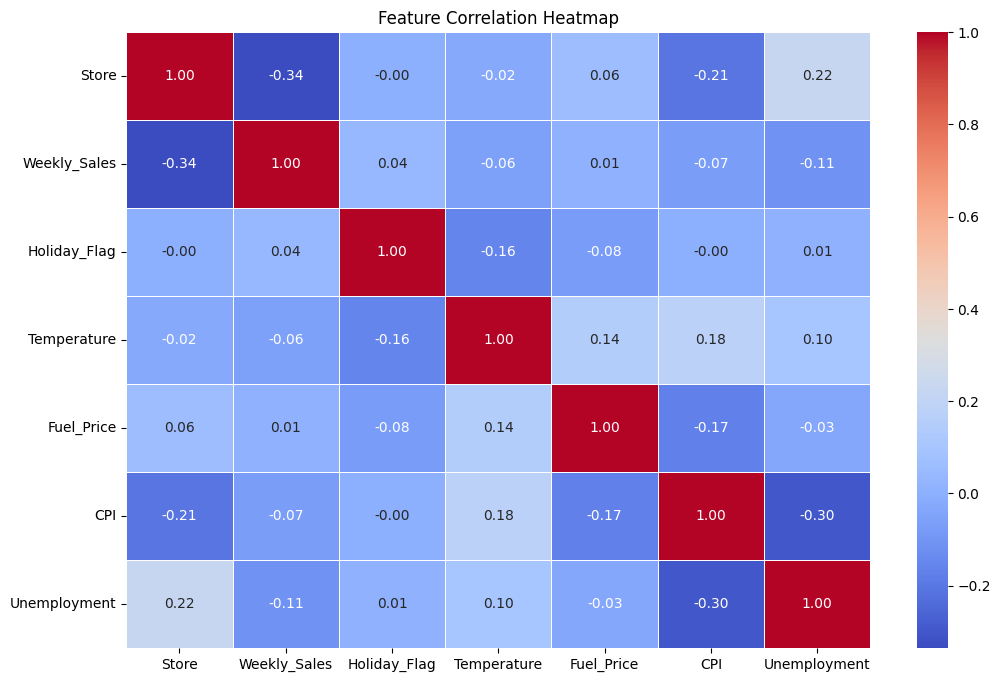

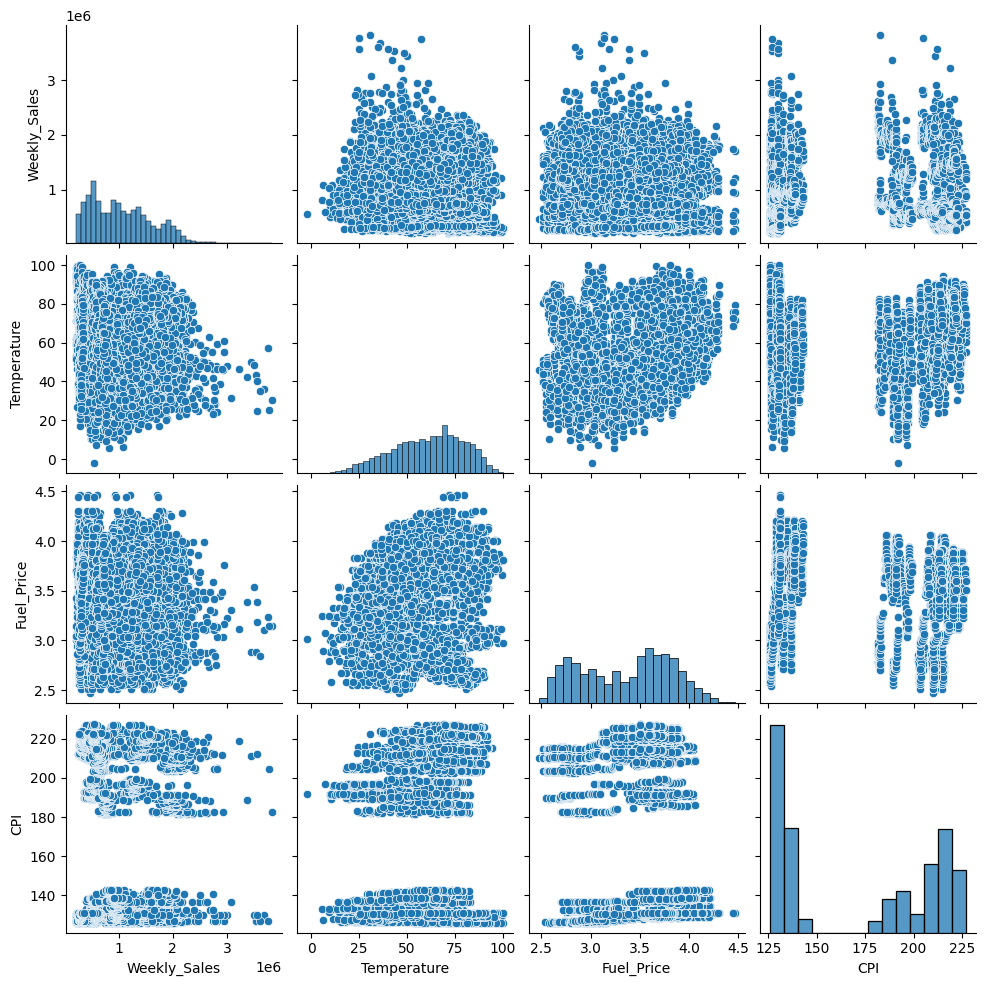

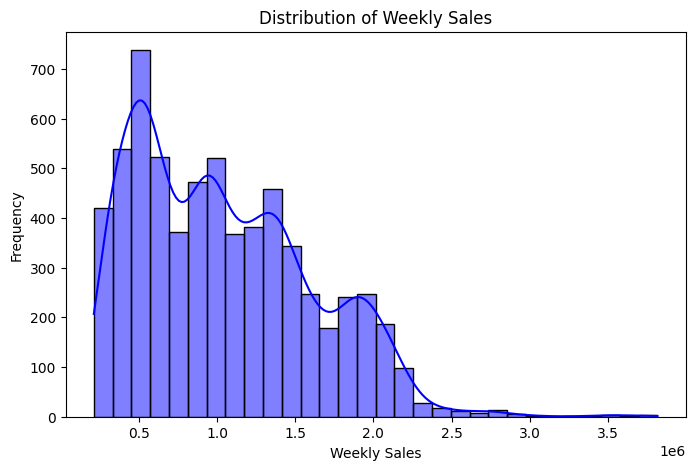

In [43]:
plt.figure(figsize=(12, 8))

df_numeric = df.select_dtypes(include=['number'])
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI']])
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [44]:


# Define features (X) and target (y)
X = df.drop(columns=["Unemployment", "Date"])  # Drop both target and non-numeric 'Date' column
y = df["Unemployment"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1662
RMSE: 1.7227


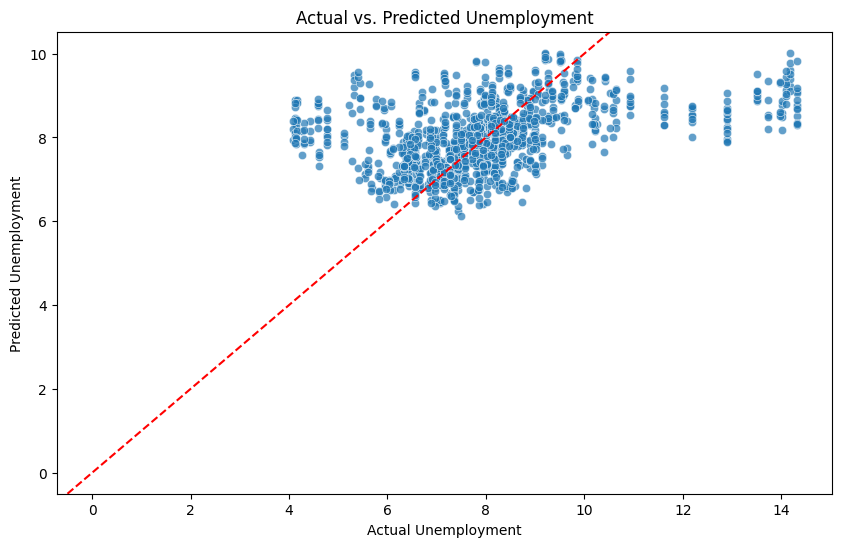

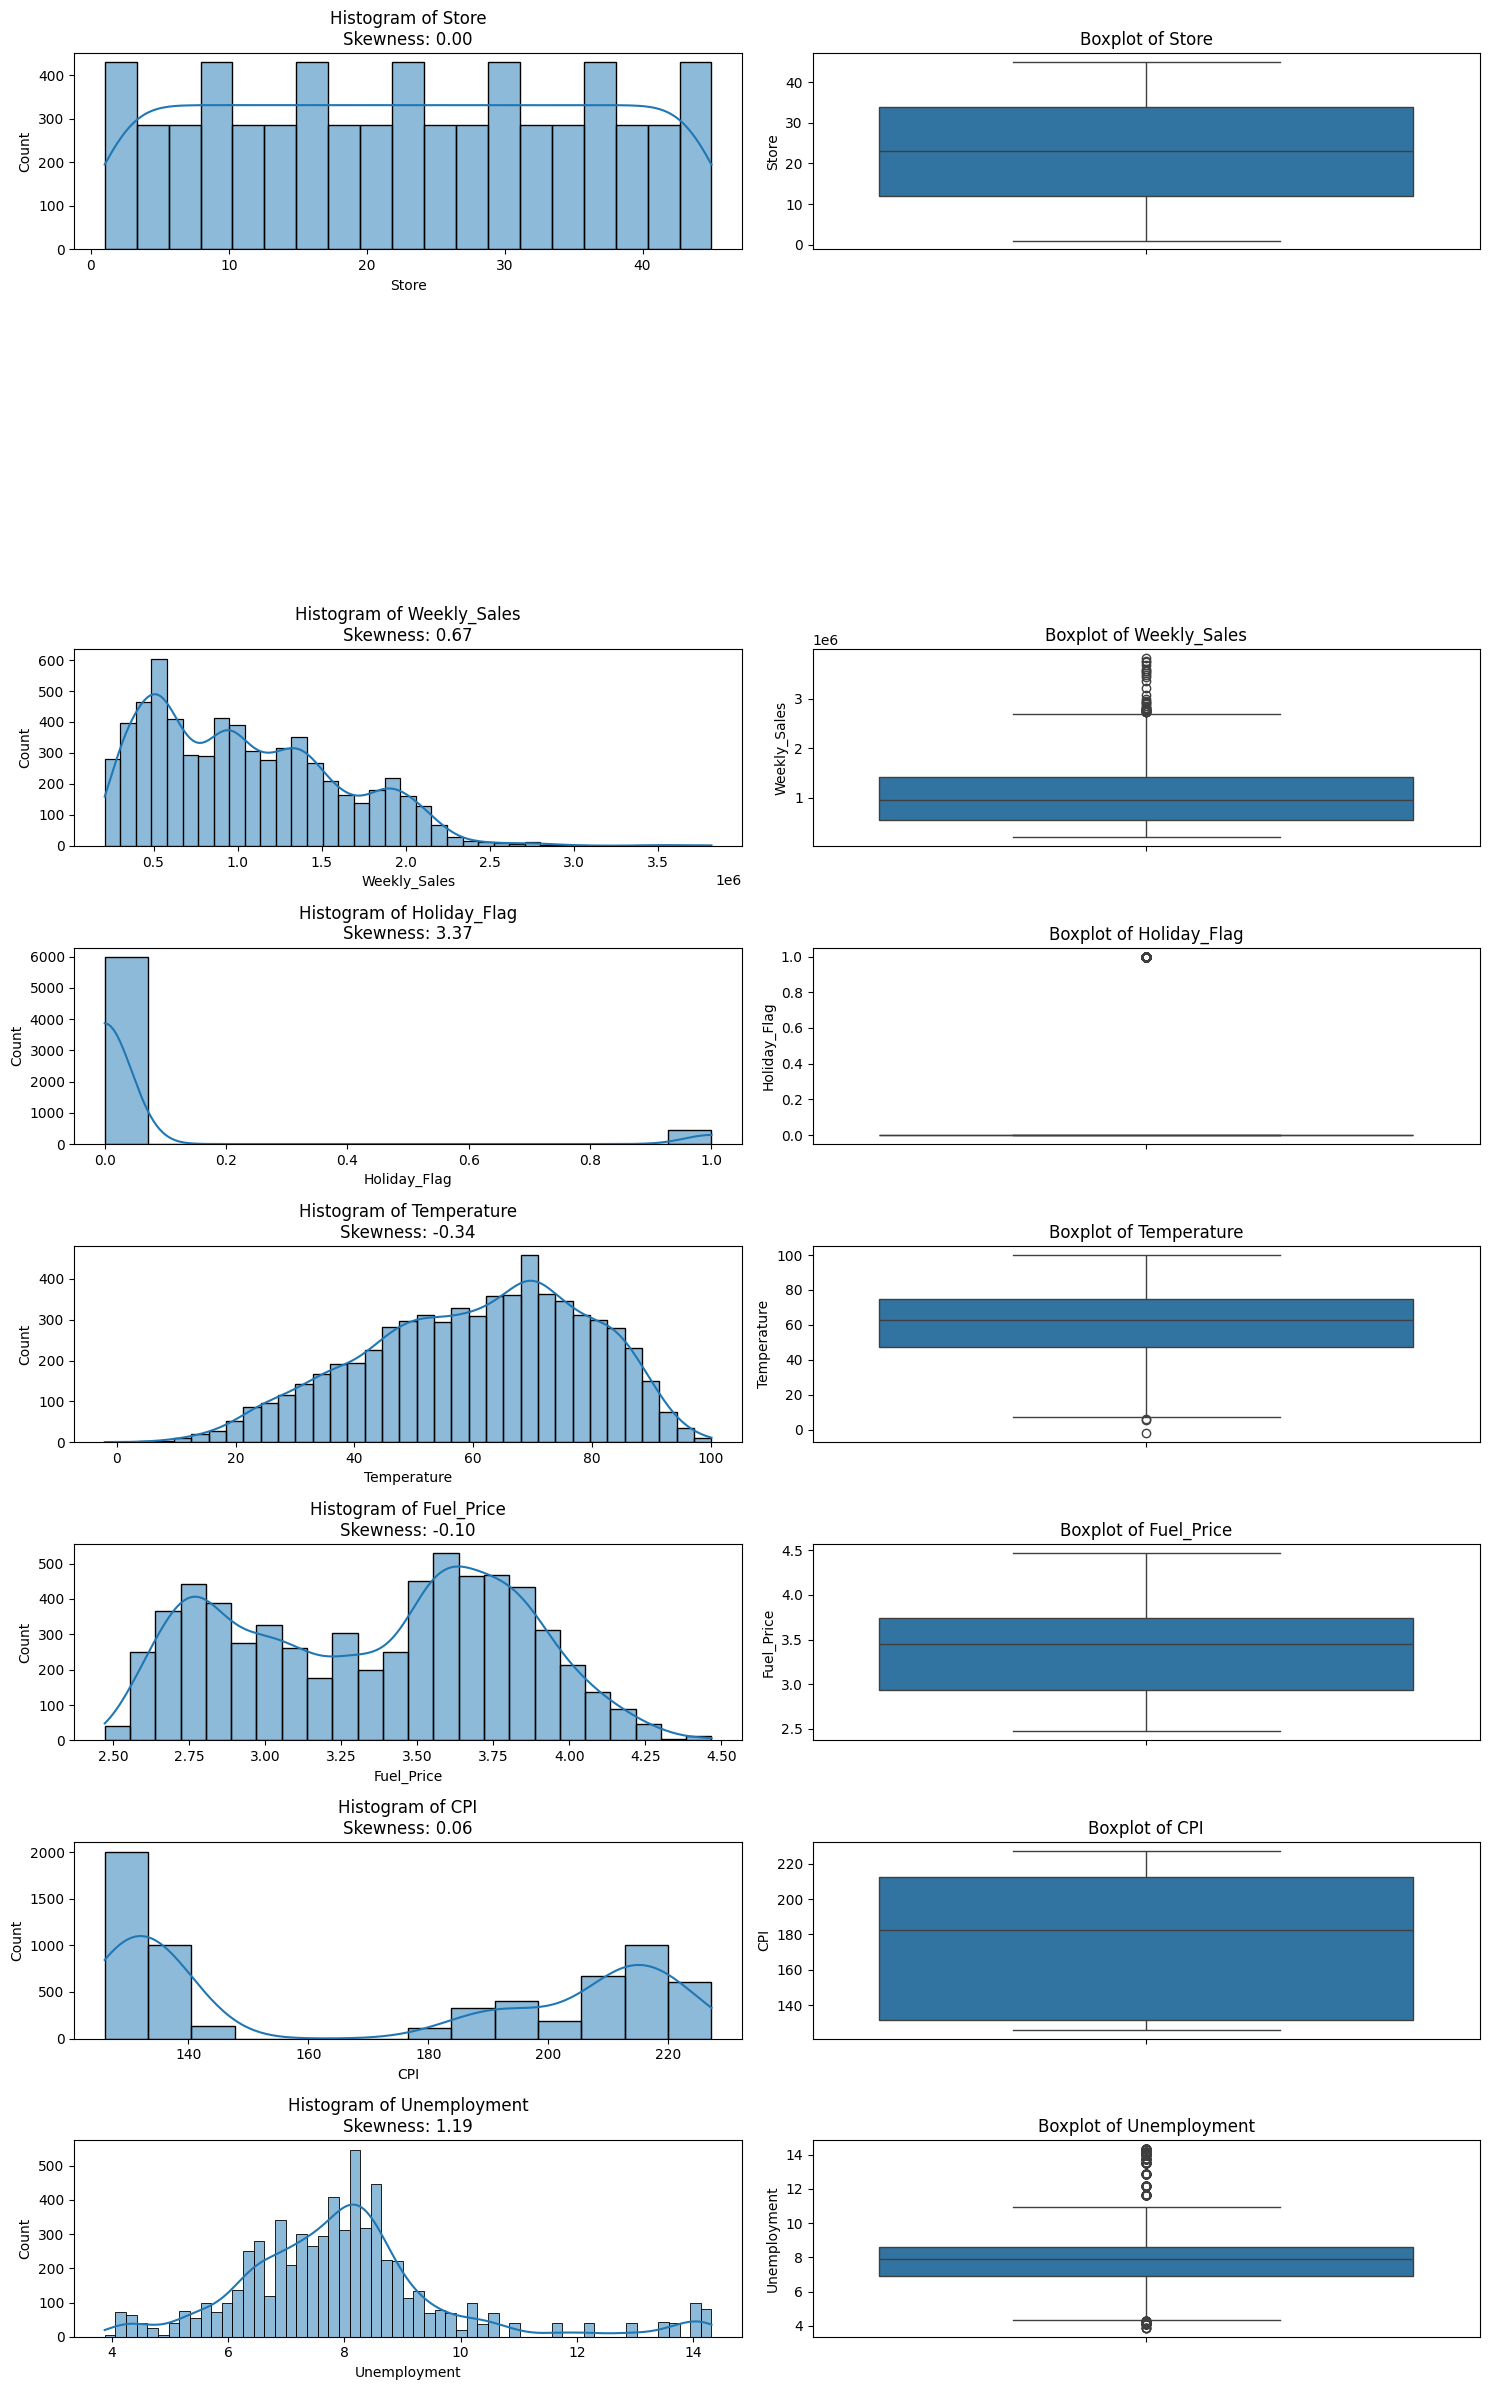

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Unemployment")
plt.ylabel("Predicted Unemployment")
plt.title("Actual vs. Predicted Unemployment")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()

# Calculate skewness only for numerical columns
skewness = df.select_dtypes(include=['number']).skew()

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
  # Ensure to only plot numerical columns
  if df[col].dtype != 'object': # Exclude object type columns (like 'Date')
    plt.subplot(num_cols,2,2*i+1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram of {col}\nSkewness: {skewness.get(col, 'N/A'):.2f}") # Use .get() for columns not in skewness

    plt.subplot(num_cols,2,2*i+2)
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [46]:

skewed_cols=df.select_dtypes(include=['number']).skew().abs()
highly_skewed = skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly skewed cols:")
print(highly_skewed)
print("negatively skewed cols:")
print(negatively_skewed)

Highly skewed cols:
Index(['Holiday_Flag', 'Unemployment'], dtype='object')
negatively skewed cols:
Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [47]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))
df[highly_skewed]

,Holiday_Flag,Unemployment
0,0.000000,2.208934
1,0.693147,2.208934
2,0.000000,2.208934
3,0.000000,2.208934
4,0.000000,2.208934
...,...,...
6430,0.000000,2.270475
6431,0.000000,2.268718
6432,0.000000,2.268718
6433,0.000000,2.268718


In [48]:


# Define features (X) and target (y)
X = df.drop(columns=["Unemployment", "Date"])  # Drop both target and non-numeric 'Date' column
y = df["Unemployment"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1434
RMSE: 0.1854


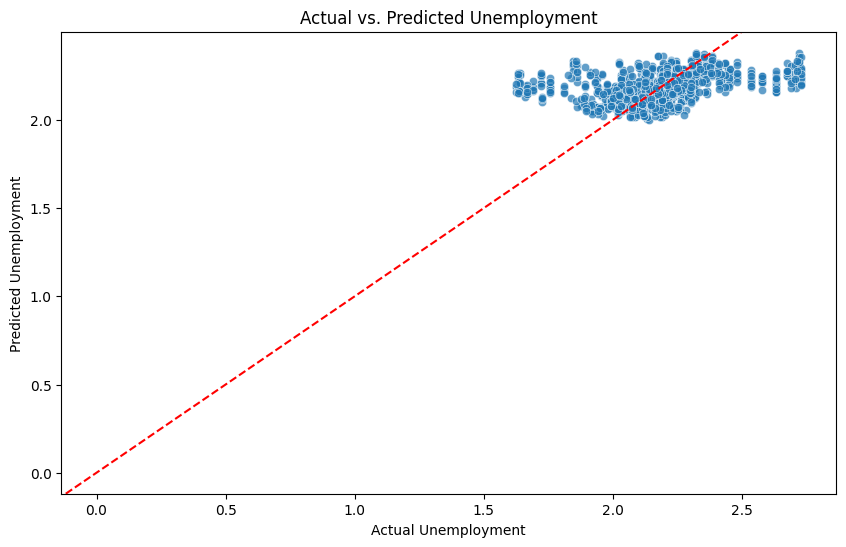

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Unemployment")
plt.ylabel("Predicted Unemployment")
plt.title("Actual vs. Predicted Unemployment")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()



In [50]:


#train random forest
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#predictions
y_pred_rf=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred_rf)
rmse=mean_squared_error(y_test,y_pred_rf)**0.5

print(f"Random forest r2 score: {r2:.4f}")
print(f"Random forest RMSE: {rmse:.4f}")

Random forest r2 score: 0.9898
Random forest RMSE: 0.0202
